### SVM with RBF Kernel — 10 Epochs

Support Vector Machine using an RBF kernel. Implement a training loop that runs for **10 epochs**, and plot training and validation **loss** and **accuracy** per epoch.

Implementation notes:
- scikit-learn's `SVC` is a kernel SVM but does not support incremental training (per-epoch). To obtain per-epoch metrics we approximate the RBF kernel using `RBFSampler` (random Fourier features) and train a linear model on the transformed features with `SGDClassifier`.
- use `loss='log_loss'` so we can compute log-loss and probabilities. This is a surrogate to hinge loss but allows stable per-epoch metrics.


1. Load dataset (from the original notebook if available, otherwise we'll create a synthetic example).
2. Split into train/validation sets.
3. Apply `RBFSampler` to approximate the RBF kernel.
4. Train `SGDClassifier` for 10 epochs using `partial_fit` and record metrics.
5. Plot loss and accuracy per epoch.

In [12]:
# Imports and helper functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score
import joblib

In [13]:
# as_frame = False returns numpy array else True gives Dataframe
digits = load_digits() # 8*8 pixel in each images = 64 features

# last column is target
X = digits.data
Y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1797, 64)
y shape: (569,)


In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [ ]:
gamma = 0.01   # IMPORTANT: digits needs smaller gamma
n_components = 500

rbf_feature = RBFSampler(gamma=gamma, n_components=n_components, random_state=42)

Z_train = rbf_feature.fit_transform(X_train)
Z_val = rbf_feature.transform(X_val)

In [ ]:
clf = SGDClassifier(
    loss="log_loss",   # allows probabilities
    max_iter=1,
    warm_start=True,
    learning_rate="optimal",
    random_state=42
)

classes = np.unique(y_train)
clf.partial_fit(Z_train[:10], y_train[:10], classes=classes)

epochs = 10
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(epochs):

    indices = np.random.permutation(len(Z_train))
    Z_train_shuffled = Z_train[indices]
    y_train_shuffled = y_train[indices]

    batch_size = 128
    for start in range(0, len(Z_train_shuffled), batch_size):
        end = start + batch_size
        clf.partial_fit(
            Z_train_shuffled[start:end],
            y_train_shuffled[start:end]
        )

    # Evaluate
    train_prob = clf.predict_proba(Z_train)
    val_prob = clf.predict_proba(Z_val)

    train_losses.append(log_loss(y_train, train_prob))
    val_losses.append(log_loss(y_val, val_prob))

    train_acc.append(accuracy_score(y_train, clf.predict(Z_train)))
    val_acc.append(accuracy_score(y_val, clf.predict(Z_val)))

    print(f"Epoch {epoch+1}: "
          f"Train Acc={train_acc[-1]:.4f}, "
          f"Val Acc={val_acc[-1]:.4f}")

Epoch 1: Train Acc=0.9819, Val Acc=0.9556
Epoch 2: Train Acc=0.9791, Val Acc=0.9556
Epoch 3: Train Acc=0.9930, Val Acc=0.9722
Epoch 4: Train Acc=0.9910, Val Acc=0.9667
Epoch 5: Train Acc=0.9923, Val Acc=0.9667
Epoch 6: Train Acc=0.9889, Val Acc=0.9694
Epoch 7: Train Acc=0.9937, Val Acc=0.9667
Epoch 8: Train Acc=0.9951, Val Acc=0.9694
Epoch 9: Train Acc=0.9944, Val Acc=0.9694
Epoch 10: Train Acc=0.9930, Val Acc=0.9667


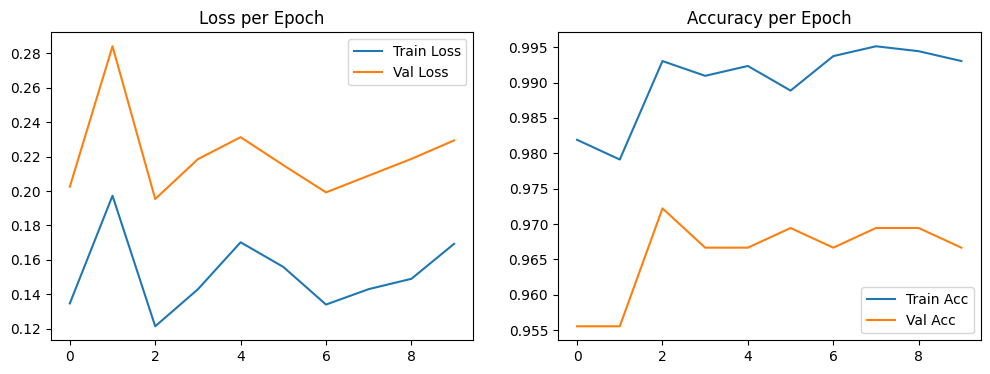

In [19]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss per Epoch")

plt.subplot(1,2,2)
plt.plot(train_acc, label="Train Acc")
plt.plot(val_acc, label="Val Acc")
plt.legend()
plt.title("Accuracy per Epoch")

plt.show()

### Notes, assumptions, and limitations

- We approximated the RBF kernel using `RBFSampler` (random Fourier features). This allows incremental training with linear models and gives us per-epoch metrics.
- We trained a logistic-loss linear classifier (`SGDClassifier(loss='log_loss')`) on the RBF features. This is a convex surrogate to the SVM hinge loss. If you require exact SVM hinge loss, you can use `SGDClassifier(loss='hinge')` but `log_loss` provides probabilities and stable `log_loss` metric.
- `gamma` (kernel width), `n_components` (number of random features), and SGD hyperparameters are important. Use validation or grid search to tune.
- If you prefer exact kernel SVM, use `sklearn.svm.SVC(kernel='rbf')`, but it does not support `partial_fit` or simple epoch-by-epoch logging.

#### Next steps / improvements

1. Hyperparameter tuning for `gamma`, `n_components`, learning rate, and regularization.
2. Switch to `loss='hinge'` if you want a closer approximation to SVM hinge loss. Note that `hinge` does not provide probability estimates.
3. Use more `n_components` for a better RBF approximation at increased cost.

#### Files produced

- `rbf_svm.ipynb` — this notebook
- `rbf_svm_artifacts.pkl` — saved model, scaler, and RBFSampler
